# Online News Popularity — Exploratory Data Analysis

**Objective.** Predict the number of times a news article is shared (`shares`) from its
content, metadata, and keyword statistics. `shares` is a continuous count, so this is a
**regression** problem.

**What this notebook does.** Understand the data, document data-quality issues, study how each
feature relates to the target, and decide the preprocessing and modelling strategy. Every
cleaning rule here is mirrored in `src/data_preparation.py` so the analysis and the pipeline
stay in sync. Selected summaries are written to `./reports/`.

**Headline finding (stated up front).** `shares` is *extremely* right-skewed and only weakly
related to any single feature, so this is a genuinely hard prediction task — realistic R² is
modest. We therefore model **log1p(shares)** and report metrics on both the log and original
scales, leaning on the log scale because raw-scale R² is dominated by a few viral outliers.

## 1. Setup and data loading

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from scipy import stats
from sklearn.linear_model import LinearRegression

sys.path.append(".")
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

REPORTS = Path("reports"); REPORTS.mkdir(exist_ok=True)

with open("src/config.yaml") as f:
    config = yaml.safe_load(f)
TARGET = config["target_column"]

df = pd.read_csv(config["file_path"])
print("Shape:", df.shape, "| target:", TARGET)
df.head()

Shape: (35680, 30) | target: shares


,ID,URL,timedelta,weekday,shares,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,n_comments,average_token_length,data_channel,self_reference_min_shares,self_reference_max_shares,self_reference_avg_shares,num_keywords,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg
0,0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,monday,593,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,0.0,4.680365,entertainment,496.0,496.0,496.000000,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,monday,711,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,NaN,28.0,4.913725,business,0.0,0.0,0.000000,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,monday,1500,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,15.0,4.393365,business,918.0,918.0,918.000000,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,monday,1200,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,72.0,4.404896,entertainment,0.0,0.0,0.000000,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,monday,505,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,NaN,20.0,4.682836,technology,545.0,16000.0,3151.157895,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35680 entries, 0 to 35679
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         35680 non-null  int64  
 1   URL                        35680 non-null  str    
 2   timedelta                  35680 non-null  float64
 3   weekday                    35680 non-null  str    
 4   shares                     35680 non-null  int64  
 5   n_tokens_title             35680 non-null  float64
 6   n_tokens_content           35680 non-null  float64
 7   n_unique_tokens            35680 non-null  float64
 8   n_non_stop_words           35680 non-null  float64
 9   n_non_stop_unique_tokens   35680 non-null  float64
 10  num_hrefs                  34959 non-null  float64
 11  num_self_hrefs             34959 non-null  float64
 12  num_imgs                   34261 non-null  float64
 13  num_videos                 18925 non-null  float64
 14  n

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,35680.0,19823.468918,11452.292291,0.0,9890.750000,19801.500000,29788.250000,39643.000000
timedelta,35680.0,354.523234,214.301086,8.0,163.000000,339.000000,543.000000,731.000000
shares,35680.0,3402.054961,11934.878541,4.0,946.000000,1400.000000,2800.000000,843300.000000
n_tokens_title,35680.0,10.395432,2.114600,2.0,9.000000,10.000000,12.000000,23.000000
n_tokens_content,35680.0,545.995123,469.550052,0.0,247.000000,410.000000,716.000000,8474.000000
n_unique_tokens,35680.0,0.530461,0.136935,0.0,0.471030,0.539011,0.608203,1.000000
n_non_stop_words,35680.0,0.970263,0.169862,0.0,1.000000,1.000000,1.000000,1.000000
n_non_stop_unique_tokens,35680.0,0.672738,0.153881,0.0,0.625912,0.690323,0.754036,1.000000
num_hrefs,34959.0,10.866358,11.260971,0.0,4.000000,8.000000,14.000000,304.000000
num_self_hrefs,34959.0,3.282531,3.834065,0.0,1.000000,3.000000,4.000000,116.000000


**First observations.**

- ~35.7k articles, 30 columns. Target `shares` is a count.
- Two identifier columns — `ID` and `URL` — carry no predictive signal and are dropped.
- Two text categoricals: `weekday` (day of publication) and `data_channel` (article topic).
- The rest are numeric: article structure (`n_tokens_*`, `num_hrefs`, `num_imgs`, …), keyword
  share statistics (`kw_*`), self-reference shares, and `n_comments`.
- `describe()` shows the classic issues of this dataset: `shares` has a huge max relative to its
  median (heavy right tail), and several columns have far fewer non-null entries than rows.

## 2. Data quality checks

In [4]:
missing = df.isna().sum()
missing[missing > 0].to_frame("missing_count").assign(
    pct=lambda d: (d["missing_count"] / len(df) * 100).round(2)).sort_values("pct", ascending=False)

,missing_count,pct
num_videos,16755,46.96
data_channel,5462,15.31
num_imgs,1419,3.98
num_self_hrefs,721,2.02
num_hrefs,721,2.02
self_reference_min_shares,721,2.02
self_reference_max_shares,721,2.02
self_reference_avg_shares,721,2.02


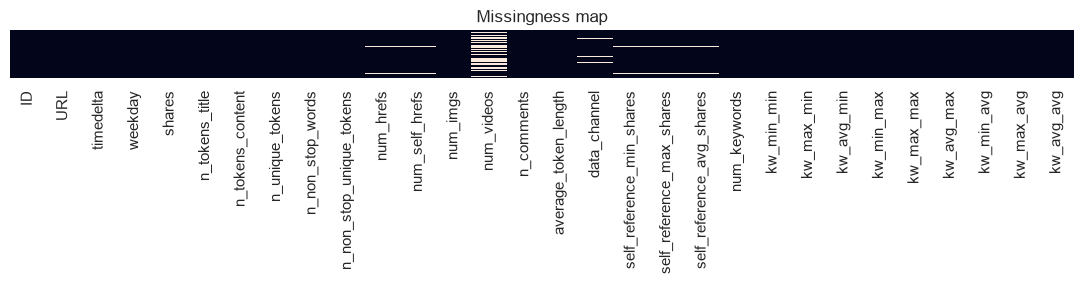

In [5]:
fig, ax = plt.subplots(figsize=(11, 3))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, ax=ax)
ax.set_title("Missingness map")
plt.tight_layout(); plt.show()

In [6]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated ID:", df["ID"].duplicated().sum())

# Rate features are bounded in [0, 1] by definition — check for corrupt values.
rate = ["n_unique_tokens", "n_non_stop_words", "n_non_stop_unique_tokens"]
for col in rate:
    out = ((df[col] < 0) | (df[col] > 1)).sum()
    print(f"{col}: {out} values outside [0,1] (max={df[col].max():.3g})")
print("\nArticles with 0 content tokens:", (df["n_tokens_content"] == 0).sum())

Fully duplicated rows: 0
Duplicated ID: 0
n_unique_tokens: 0 values outside [0,1] (max=1)
n_non_stop_words: 0 values outside [0,1] (max=1)
n_non_stop_unique_tokens: 0 values outside [0,1] (max=1)

Articles with 0 content tokens: 1061


**Data-quality findings.**

1. **Substantial missingness.** `num_videos` is missing for ~47% of rows, `data_channel` ~15%,
   `num_imgs` ~4%, and `num_hrefs` / `num_self_hrefs` / `self_reference_*` ~2% (the same rows).
   These are handled by imputation inside the pipeline (median for numerics; a dedicated
   `unknown` category for `data_channel` — see §5/§6).
2. **No duplicate rows** and `ID` is unique.
3. **Rate features are within [0, 1]** in this dataset (0 violations), so the pipeline's
   range-clip is a defensive guard rather than a fix for an existing error here.
4. **~1,000 articles have no content tokens.** Their text-rate features are 0 by construction;
   we keep them (they are valid "empty content" articles, not corrupt rows).

## 3. Target variable analysis

count     35680.0
mean       3402.0
std       11935.0
min           4.0
25%         946.0
50%        1400.0
75%        2800.0
max      843300.0
Name: shares, dtype: float64

Skew (raw): 34.41 | Skew (log1p): 1.04
Quantiles: {0.5: 1400, 0.9: 6200, 0.99: 32000, 0.999: 112532}


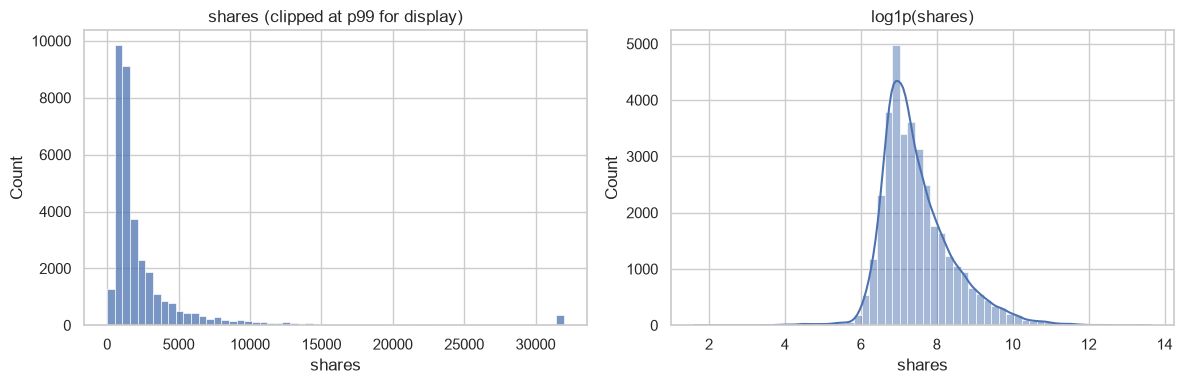

In [7]:
print(df[TARGET].describe().round(0))
print("\nSkew (raw):", round(df[TARGET].skew(), 2),
      "| Skew (log1p):", round(np.log1p(df[TARGET]).skew(), 2))
print("Quantiles:", {q: round(df[TARGET].quantile(q)) for q in [0.5, 0.9, 0.99, 0.999]})

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[TARGET].clip(upper=df[TARGET].quantile(0.99)), bins=60, ax=ax[0])
ax[0].set_title("shares (clipped at p99 for display)")
sns.histplot(np.log1p(df[TARGET]), bins=60, kde=True, ax=ax[1])
ax[1].set_title("log1p(shares)")
plt.tight_layout(); plt.show()

**Target observations.** `shares` ranges from 4 to ~843,000 with a median of only ~1,400 — a
**skew of ~34**. A handful of viral articles dominate the upper tail. The `log1p` transform
collapses the skew to ~1.0 and yields a roughly bell-shaped target. We therefore **train on
`log1p(shares)`** and inverse-transform predictions. This also explains why raw-scale R² is an
unreliable score here: a single mispredicted viral article inflates squared error enormously,
so we report and select on **log-scale** metrics and use **MAE** as the interpretable
original-scale figure.

## 4. Cleaning validation

In [8]:
from src.data_preparation import DataPreparation
prep = DataPreparation(config)
before = df.shape
clean = prep.clean_data(df.copy())
print(f"Cleaning shape change: {before} -> {clean.shape}")
print("Dropped columns present?:", [c for c in ['ID', 'URL'] if c in clean.columns])
print("Columns:", list(clean.columns))
clean.head(3)

Cleaning shape change: (35680, 30) -> (35680, 28)
Dropped columns present?: []
Columns: ['timedelta', 'weekday', 'shares', 'n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos', 'n_comments', 'average_token_length', 'data_channel', 'self_reference_min_shares', 'self_reference_max_shares', 'self_reference_avg_shares', 'num_keywords', 'kw_min_min', 'kw_max_min', 'kw_avg_min', 'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg']


,timedelta,weekday,shares,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,n_comments,average_token_length,data_channel,self_reference_min_shares,self_reference_max_shares,self_reference_avg_shares,num_keywords,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg
0,731.0,monday,593,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,0.0,4.680365,entertainment,496.0,496.0,496.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,731.0,monday,711,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,NaN,28.0,4.913725,business,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,731.0,monday,1500,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,15.0,4.393365,business,918.0,918.0,918.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Validation.** Cleaning drops the `ID`/`URL` identifiers, removes any exact duplicate rows, and
NaN-coerces any rate value outside [0, 1] (none here). Imputation, scaling, and encoding then
happen inside the model pipeline, fit on training data only, to avoid leakage.

## 5. Categorical feature profiling


weekday (7 categories, 0 missing)
weekday
wednesday    6663
tuesday      6646
thursday     6563
monday       5977
friday       5147
sunday       2472
saturday     2212

data_channel (6 categories, 5462 missing)
data_channel
world            7573
technology       6642
entertainment    6407
business         5623
NaN              5462
social_media     2089
lifestyle        1884


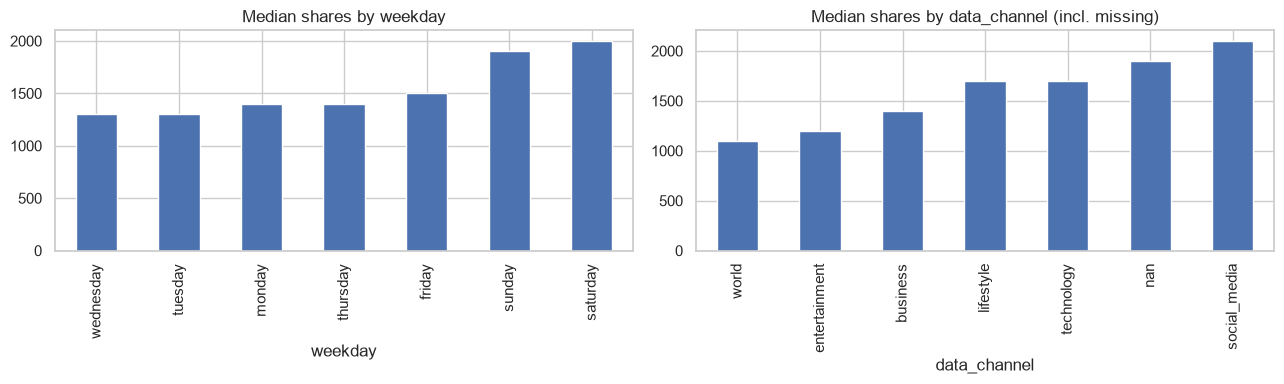

In [9]:
for col in ["weekday", "data_channel"]:
    print(f"\n{col} ({df[col].nunique()} categories, {df[col].isna().sum()} missing)")
    print(df[col].value_counts(dropna=False).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df.groupby("weekday")[TARGET].median().sort_values().plot(
    kind="bar", ax=ax[0], title="Median shares by weekday")
df.groupby("data_channel", dropna=False)[TARGET].median().sort_values().plot(
    kind="bar", ax=ax[1], title="Median shares by data_channel (incl. missing)")
plt.tight_layout(); plt.show()

**Categorical observations.**

- **Weekend effect:** articles published on Saturday/Sunday have a clearly higher median share
  count (~1,900–2,000) than weekdays (~1,300–1,500). `weekday` carries real signal and is
  one-hot encoded.
- **Channel effect:** `social_media` and `lifestyle`/`technology` articles are shared more than
  `world`/`entertainment`. The **missing** `data_channel` rows have a distinct (relatively high)
  median, so we treat "missing" as its own `unknown` category rather than imputing a real
  channel — the absence is itself informative.

## 6. Missingness analysis

In [10]:
# Is num_videos missingness informative about the target, or just noise?
logshares = np.log1p(df[TARGET])
print("Mean log-shares  | num_videos missing: %.3f | present: %.3f"
      % (logshares[df["num_videos"].isna()].mean(), logshares[df["num_videos"].notna()].mean()))
print("Mean log-shares  | data_channel missing: %.3f | present: %.3f"
      % (logshares[df["data_channel"].isna()].mean(), logshares[df["data_channel"].notna()].mean()))

Mean log-shares  | num_videos missing: 7.476 | present: 7.475
Mean log-shares  | data_channel missing: 7.820 | present: 7.413


**Missingness decision.** `num_videos` missingness is **uninformative** — the mean log-shares of
the missing and present groups are essentially identical — so plain median imputation is
appropriate (no signal is lost). By contrast, missing `data_channel` *does* shift the target, so
it is preserved as an explicit `unknown` category (§5).

## 7. Feature–target relationships

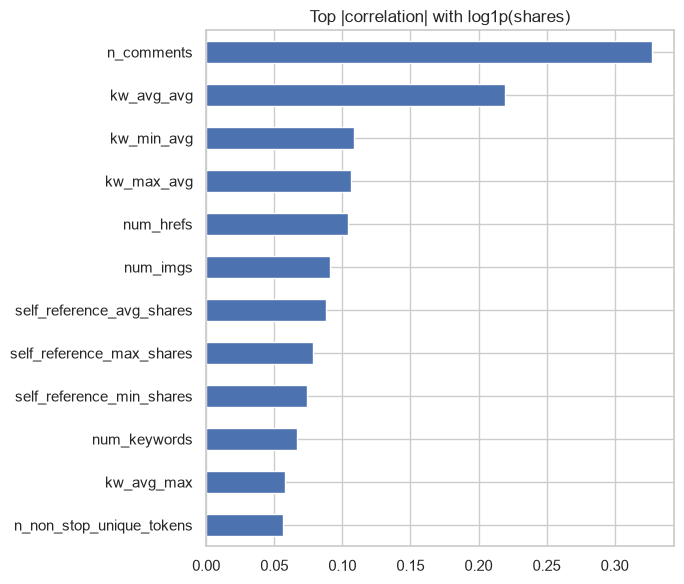

n_comments                   0.327
kw_avg_avg                   0.219
kw_min_avg                   0.108
kw_max_avg                   0.107
num_hrefs                    0.104
num_imgs                     0.091
self_reference_avg_shares    0.088
self_reference_max_shares    0.079
dtype: float64

In [11]:
logshares = np.log1p(df[TARGET])
num_cols = [c for c in df.select_dtypes("number").columns if c not in ("ID", TARGET)]
corr = df[num_cols].apply(lambda s: s.corr(logshares)).abs().sort_values(ascending=False)
corr.to_frame("abs_corr_with_log_shares").to_csv(REPORTS / "corr_with_target.csv")

fig, ax = plt.subplots(figsize=(7, 6))
corr.head(12).sort_values().plot(kind="barh", ax=ax,
    title="Top |correlation| with log1p(shares)")
plt.tight_layout(); plt.show()
corr.head(8).round(3)

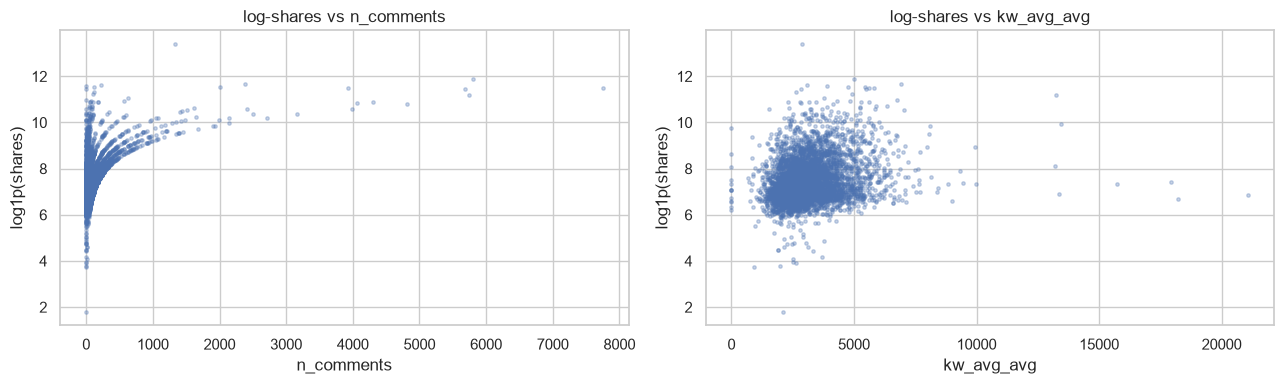

In [12]:
# Scatter for the two strongest numeric predictors (on the log target).
top2 = corr.head(2).index.tolist()
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sample = df.sample(min(5000, len(df)), random_state=0)
for a, col in zip(ax, top2):
    a.scatter(sample[col], np.log1p(sample[TARGET]), s=6, alpha=0.3)
    a.set_xlabel(col); a.set_ylabel("log1p(shares)"); a.set_title(f"log-shares vs {col}")
plt.tight_layout(); plt.show()

In [13]:
# Formal test that categorical groups differ in (log) shares: ANOVA + Kruskal-Wallis + eta^2.
def eta_squared(groups):
    allv = np.concatenate(groups); grand = allv.mean()
    ssb = sum(len(g) * (g.mean() - grand) ** 2 for g in groups)
    return ssb / ((allv - grand) ** 2).sum()

for col in ["weekday", "data_channel"]:
    groups = [np.log1p(g[TARGET].to_numpy())
              for _, g in df.dropna(subset=[col]).groupby(col)]
    f, p_a = stats.f_oneway(*groups)
    h, p_k = stats.kruskal(*groups)
    print(f"{col}: ANOVA F={f:,.1f} p={p_a:.1e} | Kruskal H={h:,.1f} p={p_k:.1e} | eta^2={eta_squared(groups):.4f}")

weekday: ANOVA F=88.0 p=5.7e-110 | Kruskal H=903.6 p=6.4e-192 | eta^2=0.0146
data_channel: ANOVA F=252.1 p=7.9e-265 | Kruskal H=1,952.1 p=0.0e+00 | eta^2=0.0401


**Relationship observations.**

- **Every predictor is weak.** The strongest numeric correlate of log-shares is `n_comments`
  (~0.33), followed by `kw_avg_avg` (~0.22); most features sit below 0.15. There is no dominant
  driver — popularity is diffuse and partly random, which is exactly why the achievable R² is
  modest and why a naive baseline is important context.
- **Categoricals are significant but small.** ANOVA and Kruskal–Wallis both reject "no
  difference" for `weekday` and `data_channel` (tiny p-values), but the **η²** effect sizes are
  small — they matter, yet explain only a few percent of variance on their own. (ANOVA assumes
  normal, equal-variance groups, which the skew violates; we report Kruskal–Wallis alongside and
  lean on it.)
- The scatter plots show broad clouds rather than tight trends — consistent with the weak
  correlations and a hard target.

## 8. Outlier review (IQR)

In [14]:
def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75); iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

num_for_outliers = [c for c in df.select_dtypes("number").columns if c not in ("ID",)]
rows = []
for col in num_for_outliers:
    lo, hi = iqr_bounds(df[col].dropna())
    mask = (df[col] < lo) | (df[col] > hi)
    rows.append({"feature": col, "n_outliers": int(mask.sum()),
                 "pct": round(mask.mean() * 100, 2)})
outlier_summary = pd.DataFrame(rows).sort_values("pct", ascending=False)
outlier_summary.to_csv(REPORTS / "outlier_summary.csv", index=False)
outlier_summary.head(12)

,feature,n_outliers,pct
21,kw_max_max,8505,23.84
9,num_imgs,6614,18.54
20,kw_min_max,4581,12.84
13,self_reference_min_shares,4388,12.30
17,kw_min_min,4218,11.82
1,shares,4080,11.43
14,self_reference_max_shares,3765,10.55
15,self_reference_avg_shares,3728,10.45
11,n_comments,3461,9.70
18,kw_max_min,3262,9.14


**Outlier decision.** Many features (including the target and the keyword/self-reference share
columns) are heavy-tailed with sizeable IQR-outlier fractions, but these are **genuine** extreme
articles, not data errors. Rather than clip and lose the very signal that distinguishes viral
content, we (a) model the **log** target to compress the tail and (b) use **tree-based** models
that are robust to skew and extreme values.

## 9. Multicollinearity

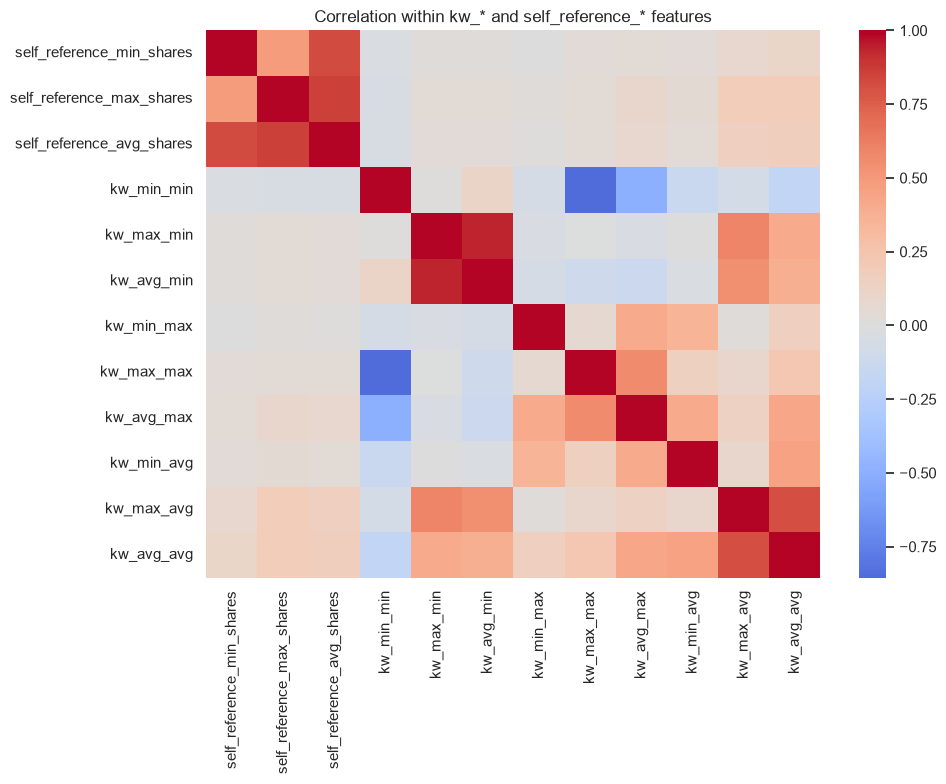

In [15]:
# The keyword (kw_*) and self_reference_* families are internally very correlated.
kw_self = [c for c in num_cols if c.startswith("kw_") or c.startswith("self_reference")]
corrm = df[kw_self].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corrm, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation within kw_* and self_reference_* features")
plt.tight_layout(); plt.show()

In [16]:
def vif_table(frame, cols):
    frame = frame[cols].dropna()
    out = []
    for col in cols:
        others = [c for c in cols if c != col]
        r2 = LinearRegression().fit(frame[others], frame[col]).score(frame[others], frame[col])
        out.append({"feature": col, "VIF": round(1 / (1 - r2), 1) if r2 < 1 else np.inf})
    return pd.DataFrame(out).sort_values("VIF", ascending=False)

vif = vif_table(df, kw_self)
vif.to_csv(REPORTS / "vif.csv", index=False)
vif

,feature,VIF
2,self_reference_avg_shares,19.4
4,kw_max_min,10.3
5,kw_avg_min,9.8
1,self_reference_max_shares,8.3
11,kw_avg_avg,6.7
0,self_reference_min_shares,6.7
10,kw_max_avg,5.8
7,kw_max_max,4.2
3,kw_min_min,3.8
8,kw_avg_max,2.5


**Multicollinearity note.** The `kw_*` keyword-statistic columns and the three
`self_reference_*` share columns are highly collinear within their families (high VIFs) — they
are different summaries of the same underlying quantities. This destabilises linear-model
coefficients, another reason to include **regularised** linear models (Ridge/Lasso) and
**tree ensembles**, which tolerate correlated inputs. We keep the features (they still carry
predictive value collectively) and rely on the models to handle the redundancy.

## 10. Conclusion — findings, preprocessing, and modelling hypotheses

| EDA finding | Preprocessing / modelling decision |
|---|---|
| `shares` skew ~34, viral tail | Model `log1p(shares)`; report log-scale metrics + MAE |
| `ID`, `URL` are identifiers | Drop |
| `num_videos` 47% missing, uninformative | Median-impute |
| `data_channel` 15% missing, informative | Keep missing as an `unknown` one-hot category |
| Other numeric gaps (num_hrefs, self_reference_*) | Median-impute inside the pipeline |
| Rate features bounded [0,1] | Range-clip guard → NaN → impute |
| `weekday`, `data_channel` significant (small η²) | One-hot encode |
| Heavy-tailed features; real outliers | Scale numerics; prefer tree ensembles |
| `kw_*` / `self_reference_*` collinear (high VIF) | Keep; use regularised + tree models |

**Modelling hypotheses (before training):**

- No single feature dominates, so **linear models will only reach a low R²**; `n_comments` and
  `kw_avg_avg` will be among the more useful inputs.
- **Tree ensembles (RandomForest / HistGradientBoosting) should modestly beat the linear
  models** on the log target by capturing weak non-linear interactions, but the gain will be
  smaller than in an "easy" dataset — the ceiling here is low.
- The **DummyRegressor** (predict the mean) should sit at R²≈0, framing how much signal the real
  models actually add.
- Raw-scale R² will look poor/unstable because of viral outliers; **log-scale R² and MAE are the
  honest scores.**

**Next (modelling).** Impute + scale numerics and one-hot encode categoricals inside a
`ColumnTransformer`/`Pipeline` (fit on training only), then compare a `DummyRegressor` baseline
against Linear/Ridge/Lasso and RandomForest/HistGradientBoosting, tuned with cross-validated
search, selecting on validation **log-scale R²**.